In [ ]:
!pip -q install opencv-python scipy numpy tqdm
import torch, torchvision
import re
import cv2
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
import random, os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

RAW= "/content/drive/MyDrive/OpacityModelTraining2/Datasets"
OUT= "/content/drive/MyDrive/OpacityModelTraining2/SLITNet_processed"
WHITE_DIR=os.path.join(RAW,"White_Light")
ANN_PATH= os.path.join(RAW, "annotations.mat")
IDXS_PATH= os.path.join(RAW, "idxs.mat")

os.makedirs(os.path.join(OUT,"images"), exist_ok=True)
os.makedirs(os.path.join(OUT,"masks"), exist_ok=True)
os.makedirs(os.path.join(OUT,"splits"), exist_ok=True)

print("WHITE_DIR exists:", os.path.isdir(WHITE_DIR))
print("ANN exists:", os.path.isfile(ANN_PATH))
print("IDXS exists:", os.path.isfile(IDXS_PATH))


WHITE_DIR exists: True
ANN exists: True
IDXS exists: True


In [ ]:
!pip -q install mat73 h5py imageio

import os, gc
import cv2
import numpy as np
import mat73
import h5py
import imageio.v2 as imageio

cv2.setNumThreads(0)  #reduce Colab CPU/RAM spikes

RAW="/content/drive/MyDrive/OpacityModelTraining2/Datasets"
OUT="/content/drive/MyDrive/OpacityModelTraining2/SLITNet_processed"

WHITE_DIR = os.path.join(RAW, "White_Light")
ANN_PATH = os.path.join(RAW, "annotations.mat")
IDXS_PATH= os.path.join(RAW, "idxs.mat")

os.makedirs(os.path.join(OUT, "images"), exist_ok=True)
os.makedirs(os.path.join(OUT, "masks"), exist_ok=True)
os.makedirs(os.path.join(OUT, "splits"), exist_ok=True)

#first preprocessing was wrong so tried this version
#support tif files
def listWhiteImages():
  files = [f for f in os.listdir(WHITE_DIR)
            if f.lower().endswith((".png", ".jpg", ".jpeg", ".tif", ".tiff"))]
  files.sort()
  return files

def normalise_id(fn):
  return os.path.splitext(fn)[0]

def save_split(name, ids):
  p = os.path.join(OUT, "splits", f"{name}.txt")
  with open(p, "w", encoding="utf-8") as f:
      for sid in ids:
          f.write(sid + "\n")

#to read image safely
def readImage(path):
  img= cv2.imread(path, cv2.IMREAD_COLOR)
  if img is not None:
      return img
  arr= imageio.imread(path)
  if arr.ndim== 2:
      arr=np.stack([arr] * 3, axis=-1)
  if arr.dtype!=np.uint8:
      mx=float(arr.max()) if arr.size else 255.0
      if mx<=0:
          mx=255.0
      arr=(arr.astype(np.float32) / mx * 255.0).clip(0, 255).astype(np.uint8)
  return cv2.cvtColor(arr, cv2.COLOR_RGB2BGR)

def ensure_uint8_mask(mask01):
  return ((mask01 > 0).astype(np.uint8) * 255)

# This Maps fold indices to actual image IDs like V000
def idx_to_ids(idx_arr, available_ids, strict=False):
  out,missing = [],[]
  for i in np.array(idx_arr).astype(int).flatten():
      cand0= f"V{i:03d}"
      cand1= f"V{i-1:03d}"
      if cand0 in available_ids:
          out.append(cand0)
      elif cand1 in available_ids:
          out.append(cand1)
      else:
          missing.append(int(i))

  seen,out2=set(),[]
  for x in out:
      if x not in seen:
          out2.append(x);seen.add(x)
  if missing:
      msg=f"Warning: {len(missing)} indices not found (showing 10):{missing[:10]}"
      if strict:
          raise IndexError(msg)
      print(msg)
  return out2

#Instead of pretending the file directly contains train/val/test this treats k1 to k7 as 7 folds.
#annotations.mat turned out to store bounding boxes not masks
def make_splits_from_folds(idxs, available_ids,test_fold=1):
  keys=[f"k{i}" for i in range(1, 8)]
  for k in keys:
      if k not in idxs:
        raise RuntimeError(f"Missing {k} in idxs.mat. Found:{list(idxs.keys())}")

  k_test= f"k{test_fold}"
  k_val= f"k{(test_fold % 7) + 1}"
  train_keys= [k for k in keys if k not in [k_test,k_val]]

  test_idx = np.array(idxs[k_test]).squeeze()
  val_idx= np.array(idxs[k_val]).squeeze()
  train_idx= np.concatenate([np.array(idxs[k]).squeeze().reshape(-1) for k in train_keys],axis=0)

  train_ids=idx_to_ids(train_idx,available_ids)
  val_ids=idx_to_ids(val_idx,available_ids)
  test_ids=idx_to_ids(test_idx,available_ids)
  return train_ids,val_ids,test_ids,(k_test,k_val,train_keys)

#search through the HDF5 structure inside annotations.mat to find a dataset that looks like the main annotation reference table.
#this tells me the annotation file stores bounding boxes and not dense masks
def findRefData(h5f,target_n=133,tol=300):
  candidates=[]
  def visitor(name,obj):
      if not isinstance(obj,h5py.Dataset):
          return
      dt=obj.dtype
      is_ref_like=(dt == object) or (hasattr(dt, "kind") and dt.kind == "O")
      if not is_ref_like:
          return
      n=int(np.prod(obj.shape)) if obj.shape else 0
      if n<=0:
          return
      if abs(n-target_n)<=tol:
          candidates.append((abs(n - target_n), n, name))

  h5f.visititems(visitor)
  if candidates:
    candidates.sort(key=lambda x: (x[0], x[1]))
    return candidates[0][2]


  refish=[]
  def visitor2(name,obj):
      if isinstance(obj,h5py.Dataset):
          dt=obj.dtype
          is_ref_like=(dt == object) or (hasattr(dt, "kind") and dt.kind=="O")
          if is_ref_like:
              n=int(np.prod(obj.shape)) if obj.shape else 0
              if n>0:
                refish.append((n, name))
  h5f.visititems(visitor2)
  if not refish:
      raise RuntimeError("No ref-like dataset found in annotations.mat")
  refish.sort(key=lambda x:x[0])
  return refish[0][1]

#Convert a bounding box into a binary mask image : this function turns rectangle annotations into segmentation masks
def bbox_to_mask(b, h, w):
  b=np.array(b).reshape(-1)
  if b.dtype==object or (hasattr(b.dtype, "kind") and b.dtype.kind=="O"):
    return None
  try:
    b = b.astype(float)
  except Exception:
    return None
  if b.size != 4:
    return None

  x1,y1, a,b2 = b

  # normalised coords
  if (0.0 <= x1 <= 1.0 and 0.0 <= y1 <= 1.0 and 0.0 <= a <= 1.0 and 0.0 <= b2 <= 1.0):
      x1*= w;a*=w
      y1*= h;b2*=h

  #(x1,y1,x2,y2) vs (x,y,w,h)
  if (a > x1) and (b2 > y1) and (a <= w) and (b2 <= h):
    x2, y2 = a, b2
  else:
    x2, y2 = x1 + a, y1 + b2

  x1 = int(np.clip(x1, 0, w - 1))
  y1 = int(np.clip(y1, 0, h - 1))
  x2 = int(np.clip(x2, 0, w - 1))
  y2 = int(np.clip(y2, 0, h - 1))

  m=np.zeros((h, w),dtype=np.uint8)
  if x2 > x1 and y2 > y1:
    m[y1:y2, x1:x2]=255
  return m

#Checks whether some array looks like a bounding box representation
#That helps the code recognize valid bbox data when navigating nested references
def looks_like_bbox_array(a):
  a= np.array(a)
  if a.dtype == object or (hasattr(a.dtype, "kind") and a.dtype.kind == "O"):
      return False
  a=np.array(a).squeeze()
  if a.ndim == 1 and a.size == 4:
      return True
  if a.ndim == 2 and (a.shape == (1,4) or a.shape == (4,1)):
      return True
  if a.ndim == 2 and a.shape[1] == 4 and a.shape[0] >= 1:
      return True
  return False

#follow HDF5 references until we finds actual numeric bbox data
#refernec resolver
def resolve_first_bbox_array(h5f,ref,max_depth=8):
  #annotations.mat is nested weirdly so I have to follow h5 refs
  #until I reach the actual bbox array
  seen=set()

  def walk(x,depth):
      if depth > max_depth or x is None:
        return None

      if isinstance(x, h5py.Reference):
          if not x:
              return None
          key = id(x)
          if key in seen:
              return None
          seen.add(key)
          return walk(h5f[x], depth + 1)

      if isinstance(x, h5py.Dataset):
          dt= x.dtype
          is_obj=(dt == object) or (hasattr(dt, "kind") and dt.kind == "O")
          data=x[()]
          if not is_obj:
              if looks_like_bbox_array(data):
                  return np.array(data)
              return None

          # object dataset->refs
          refs = np.array(data).ravel()
          for r in refs:
              out = walk(r, depth + 1)
              if out is not None:
                  return out
          return None

      if isinstance(x,np.ndarray):
          if looks_like_bbox_array(x):
              return x
          return None

      return None

  return walk(ref,0)

#Full pre processing pipeline
def prepare(test_fold=1,MAX_N=50,CHUNK_GC=10):
  files=listWhiteImages()
  if not files:
      raise FileNotFoundError("No images found in White_Light")

  available_ids= set(normalise_id(f) for f in files)
  print("Found images:", len(files),"| example:",files[:3])

  idxs=mat73.loadmat(IDXS_PATH)
  print("idxs keys:", [k for k in idxs.keys() if not k.startswith("__")])


  train_ids,val_ids,test_ids,info= make_splits_from_folds(idxs, available_ids, test_fold=test_fold)
  k_test,k_val,train_keys = info
  print("Fold usage:", "TEST=", k_test,"VAL=", k_val,"TRAIN folds=",train_keys)
  print("Split sizes:",len(train_ids),len(val_ids), len(test_ids))

  wanted_ids= set(train_ids + val_ids + test_ids)
  wanted_files= [f for f in files if normalise_id(f) in wanted_ids]
  print("Will process:", len(wanted_files), "images")

  with h5py.File(ANN_PATH, "r") as h5f:
      ann_path = findRefData(h5f, target_n=133, tol=300)
      A= h5f[ann_path]
      print("Annotation ref dataset:", ann_path, "shape=", A.shape, "dtype=", A.dtype)

      A_refs = np.array(A[()]).ravel()

      # Cache resolved bbox arrays by ann index
      bbox_cache = {}

      def id_to_ann_index(sid):
          return int(sid[1:])# V002 -> 2

      for j,fn in enumerate(wanted_files):
          if MAX_N is not None and j>=MAX_N:
              print("Stopped early for debug at",MAX_N)
              break

          sid= normalise_id(fn)
          img= readImage(os.path.join(WHITE_DIR, fn))
          h,w=img.shape[:2]

          ann_i=id_to_ann_index(sid)

          bbox_arr=None
          if 0 <= ann_i < len(A_refs):
              if ann_i in bbox_cache:
                  bbox_arr=bbox_cache[ann_i]
              else:
                  bbox_arr= resolve_first_bbox_array(h5f, A_refs[ann_i], max_depth=8)
                  bbox_cache[ann_i]= bbox_arr

          #building mask
          mask_u8=np.zeros((h, w), dtype=np.uint8)
          used="<empty>"

          if bbox_arr is not None:
              a= np.array(bbox_arr).squeeze()

              if a.ndim==1 and a.size == 4:
                  m = bbox_to_mask(a, h, w)
                  if m is not None:
                      mask_u8 = np.maximum(mask_u8, m)
                      used= "<bbox:vec4>"

              elif a.ndim== 2 and (a.shape == (1,4) or a.shape == (4,1)):
                  m= bbox_to_mask(a.reshape(-1), h, w)
                  if m is not None:
                      mask_u8 = np.maximum(mask_u8, m)
                      used= "<bbox:1x4>"

              elif a.ndim==2 and a.shape[1] == 4:
                  any_added=False
                  for row in a:
                      m =bbox_to_mask(row, h, w)
                      if m is not None:
                          mask_u8= np.maximum(mask_u8, m)
                          any_added= True
                  used= "<bbox:Nx4>" if any_added else "<bbox:Nx4_empty>"

          cv2.imwrite(os.path.join(OUT, "images", f"{sid}.png"), img)
          cv2.imwrite(os.path.join(OUT, "masks",  f"{sid}.png"), mask_u8)

          if j < 10:
              print(f"Example {sid}: used={used} | mask_max={mask_u8.max()} | unique={np.unique(mask_u8)[:6]}")

          del img, mask_u8
          if (j+1)%CHUNK_GC == 0:
              gc.collect()

  save_split("train",train_ids)
  save_split("val",val_ids)
  save_split("test",test_ids)

  print("Done.")
  processed_n=len(wanted_files) if MAX_N is None else min(len(wanted_files),MAX_N)
  print("Processed:",processed_n)
  print("Splits:",len(train_ids),len(val_ids),len(test_ids))

#Debug run(small)
prepare(test_fold=1,MAX_N=30,CHUNK_GC=5)


Found images: 91 | example: ['V000.tif', 'V001.tif', 'V002.tif']
idxs keys: ['k1', 'k2', 'k3', 'k4', 'k5', 'k6', 'k7']
Fold usage: TEST= k1 VAL= k2 TRAIN folds= ['k3', 'k4', 'k5', 'k6', 'k7']
Split sizes: 66 18 14
Will process: 91 images
Annotation ref dataset: data/BOUNDING_BOX shape= (133, 1) dtype= object
Example V000: used=<bbox:vec4> | mask_max=255 | unique=[  0 255]
Example V001: used=<bbox:vec4> | mask_max=255 | unique=[  0 255]
Example V002: used=<bbox:vec4> | mask_max=255 | unique=[  0 255]
Example V003: used=<bbox:vec4> | mask_max=255 | unique=[  0 255]
Example V004: used=<bbox:vec4> | mask_max=255 | unique=[  0 255]
Example V005: used=<bbox:vec4> | mask_max=255 | unique=[  0 255]
Example V006: used=<bbox:vec4> | mask_max=255 | unique=[  0 255]
Example V007: used=<bbox:vec4> | mask_max=255 | unique=[  0 255]
Example V010: used=<bbox:vec4> | mask_max=255 | unique=[  0 255]
Example V011: used=<bbox:vec4> | mask_max=255 | unique=[  0 255]
Stopped early for debug at 30
Done.
Proc

In [ ]:
#Full Run
prepare(test_fold=1, MAX_N=None, CHUNK_GC=10)


Found images: 91 | example: ['V000.tif', 'V001.tif', 'V002.tif']
idxs keys: ['k1', 'k2', 'k3', 'k4', 'k5', 'k6', 'k7']
Fold usage: TEST= k1 VAL= k2 TRAIN folds= ['k3', 'k4', 'k5', 'k6', 'k7']
Split sizes: 66 18 14
Will process: 91 images
Annotation ref dataset: data/BOUNDING_BOX shape= (133, 1) dtype= object
Example V000: used=<bbox:vec4> | mask_max=255 | unique=[  0 255]
Example V001: used=<bbox:vec4> | mask_max=255 | unique=[  0 255]
Example V002: used=<bbox:vec4> | mask_max=255 | unique=[  0 255]
Example V003: used=<bbox:vec4> | mask_max=255 | unique=[  0 255]
Example V004: used=<bbox:vec4> | mask_max=255 | unique=[  0 255]
Example V005: used=<bbox:vec4> | mask_max=255 | unique=[  0 255]
Example V006: used=<bbox:vec4> | mask_max=255 | unique=[  0 255]
Example V007: used=<bbox:vec4> | mask_max=255 | unique=[  0 255]
Example V010: used=<bbox:vec4> | mask_max=255 | unique=[  0 255]
Example V011: used=<bbox:vec4> | mask_max=255 | unique=[  0 255]
Done.
Processed: 91
Splits: 66 18 14


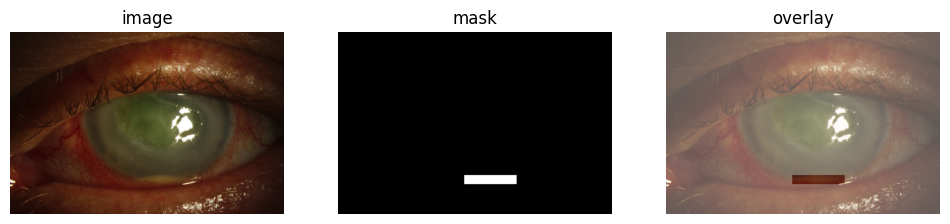

In [ ]:
#VISUALISE training image
ids= open(os.path.join(OUT, "splits", "train.txt")).read().strip().splitlines()
sid= random.choice(ids)
img= cv2.cvtColor(cv2.imread(os.path.join(OUT, "images", f"{sid}.png")), cv2.COLOR_BGR2RGB)
msk= cv2.imread(os.path.join(OUT, "masks", f"{sid}.png"), cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("image"); plt.imshow(img); plt.axis("off")
plt.subplot(1,3,2); plt.title("mask"); plt.imshow(msk, cmap="gray"); plt.axis("off")
plt.subplot(1,3,3); plt.title("overlay");
plt.imshow(img); plt.imshow(msk, cmap="Reds", alpha=0.35); plt.axis("off")
plt.show()


In [ ]:

from google.colab import drive
drive.mount("/content/drive")

import os
import cv2
import numpy as np
from dataclasses import dataclass
from typing import List

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from tqdm import tqdm

cv2.setNumThreads(0)
torch.backends.cudnn.benchmark=True

#Store all configuration settings in one place
@dataclass
class CFG:

    root:str = "/content/drive/MyDrive/OpacityModelTraining2/SLITNet_processed"
    img_dir:str = "images"
    msk_dir:str = "masks"
    split_dir:str = "splits"
    train_split:str = "train.txt"
    val_split:str= "val.txt"

    out_dir:str= "/content/drive/MyDrive/OpacityModelTraining2/runs/ulcer_unet"

    img_size:int=512
    batch_size:int=4          # lower if OOM
    num_workers:int= 2         # lower if dataloader issues
    lr:float=2e-4
    weight_decay:float=1e-4
    epochs:int=60
    seed:int=42
    amp:bool=True

#set random seeds for python/numpy etc to make rusn reproducible
def seed_all(seed=42):
  import random
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)


def read_ids(path: str) -> List[str]:
  with open(path, "r",encoding="utf-8") as f:
      return [l.strip() for l in f if l.strip()]

#resieze images /masks to specific size
def resize_square(img,size,is_mask=False):
  interp=cv2.INTER_NEAREST if is_mask else cv2.INTER_AREA
  return cv2.resize(img, (size, size), interpolation=interp)


#image only augmentation
def aug_photometric(img):
  # brightness/contrast/gamma
  img=img.astype(np.float32) / 255.0

  #contrast
  c = np.random.uniform(0.85,1.20)
  img= (img - 0.5) * c + 0.5

  #brightness
  b=np.random.uniform(-0.12, 0.12)
  img= img + b
  img= np.clip(img,0,1)

  #gamma
  g= np.random.uniform(0.85, 1.20)
  img=img ** g
  img= np.clip(img,0,1)

  return (img * 255.0).astype(np.uint8)

#Custom PyTorch dataset for loading image-mask pairs
class UlcerDataset(Dataset):
    def __init__(self, cfg: CFG, ids:List[str],augment:bool):
      self.cfg= cfg
      self.ids= ids
      self.augment= augment
      self.ip= os.path.join(cfg.root, cfg.img_dir)
      self.mp= os.path.join(cfg.root, cfg.msk_dir)

      # Precompute norm tensors on CPU
      #precompute ImageNet normalization values
      self.mean= torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
      self.std= torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

    def __len__(self):
      return len(self.ids)


    def __getitem__(self, i):
      sid = self.ids[i]
      #load items
      img_path = os.path.join(self.ip, f"{sid}.png")
      msk_path = os.path.join(self.mp, f"{sid}.png")

      img=cv2.imread(img_path,cv2.IMREAD_COLOR)
      msk=cv2.imread(msk_path,cv2.IMREAD_GRAYSCALE)
      if img is None or msk is None:
         raise FileNotFoundError(f"Missing files for id={sid} | img={os.path.isfile(img_path)} msk={os.path.isfile(msk_path)}")
      #resize+convert
      img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
      img=resize_square(img,self.cfg.img_size,is_mask=False)
      msk=resize_square(msk,self.cfg.img_size,is_mask=True)

      #binarise masks
      msk= (msk > 127).astype(np.float32)

      #augmentation
      if self.augment:
          #horizontal flip
          if np.random.rand() < 0.5:
              img=img[:, ::-1].copy()
              msk=msk[:, ::-1].copy()

          #small rotation
          if np.random.rand()<0.3:
              angle= np.random.uniform(-10, 10)
              M= cv2.getRotationMatrix2D((self.cfg.img_size/2, self.cfg.img_size/2), angle, 1.0)
              img= cv2.warpAffine(
                  img, M,(self.cfg.img_size, self.cfg.img_size),
                  flags=cv2.INTER_LINEAR,borderMode=cv2.BORDER_REFLECT_101
                )
              msk=cv2.warpAffine(
                  msk,M,(self.cfg.img_size, self.cfg.img_size),
                  flags=cv2.INTER_NEAREST, borderMode=cv2.BORDER_CONSTANT
                )

          img=aug_photometric(img)

      #conver to tensor+ImageNet normalisation
      x= torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
      x= (x-self.mean) / self.std

      y=torch.from_numpy(msk).unsqueeze(0)  # [1,H,W]
      return x, y, sid

#model
#decoder
class ConvBNReLU(nn.Module):
    def __init__(self, in_ch,out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)

#This is a UNet style decoder with a ResNet34 encoder
class UNetResNet34(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        base = models.resnet34(
            weights=models.ResNet34_Weights.IMAGENET1K_V1 if pretrained else None
        )
        #pre trained layers
        self.stem= nn.Sequential(base.conv1, base.bn1, base.relu)  # /2
        self.pool=base.maxpool                                    # /4
        self.enc1=base.layer1                                     # /4
        self.enc2=base.layer2                                     # /8
        self.enc3=base.layer3                                     # /16
        self.enc4=base.layer4                                     # /32

        #extra processing
        self.center = ConvBNReLU(512, 512)
        #Uses transpose convolutions to upsample +combine them with encoder features through skip connections
        self.up4= nn.ConvTranspose2d(512, 256, 2, 2)
        self.dec4= ConvBNReLU(256 + 256, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.dec3 = ConvBNReLU(128 + 128, 128)

        self.up2 = nn.ConvTranspose2d(128, 64,2,2)
        self.dec2 = ConvBNReLU(64 + 64, 64)

        self.up1 = nn.ConvTranspose2d(64,64,2,2)
        self.dec1 = ConvBNReLU(64 + 64,64)

        self.up0 = nn.ConvTranspose2d(64,32,2,2)
        self.dec0= ConvBNReLU(32,32)

        self.out= nn.Conv2d(32,1,1)

    #run input through decoder-> center -> decoder with skip connections -> 1 channel prediction layer
    def forward(self,x):
        x0 = self.stem(x)
        x1 = self.enc1(self.pool(x0))
        x2 = self.enc2(x1)
        x3 = self.enc3(x2)
        x4 = self.enc4(x3)

        c = self.center(x4)

        u4 = self.up4(c);  u4 = torch.cat([u4, x3], 1); d4 = self.dec4(u4)
        u3 = self.up3(d4); u3 = torch.cat([u3, x2], 1); d3 = self.dec3(u3)
        u2 = self.up2(d3); u2 = torch.cat([u2, x1], 1); d2 = self.dec2(u2)
        u1 = self.up1(d2); u1 = torch.cat([u1, x0], 1); d1 = self.dec1(u1)
        u0 = self.up0(d1); d0 = self.dec0(u0)
        return self.out(d0)


#Loss + metrics
def dice_loss(logits,y,eps=1e-6):
    p= torch.sigmoid(logits)
    num= 2 * (p * y).sum((2,3))
    den= (p + y).sum((2,3)) + eps
    return (1 - (num / den)).mean()

#This penalizes per-pixel classification mistakes
def bce_loss(logits,y):
    return F.binary_cross_entropy_with_logits(logits, y)

@torch.no_grad()
def dice_score(logits, y, thr=0.5, eps=1e-6):
    p= torch.sigmoid(logits)
    pred = (p > thr).float()
    num = 2 * (pred * y).sum((2,3))
    den = (pred + y).sum((2,3)) + eps
    return (num / den).mean().item()


#Training loop
def main():
    cfg=CFG()
    seed_all(cfg.seed)
    os.makedirs(cfg.out_dir,exist_ok=True)

    train_ids = read_ids(os.path.join(cfg.root,cfg.split_dir,cfg.train_split))
    val_ids= read_ids(os.path.join(cfg.root,cfg.split_dir,cfg.val_split))

    print("Train ids:",len(train_ids), "| Val ids:",len(val_ids))
    print("Example train id:", train_ids[0] if train_ids else None)
    print("Output dir:",cfg.out_dir)

    #DataLoaders
    train_ds= UlcerDataset(cfg,train_ids,augment=True)
    val_ds = UlcerDataset(cfg,val_ids,augment=False)

    train_loader= DataLoader(
        train_ds,batch_size=cfg.batch_size, shuffle=True,
        num_workers=cfg.num_workers, pin_memory=True, drop_last=False
    )
    val_loader= DataLoader(
        val_ds, batch_size=cfg.batch_size, shuffle=False,
        num_workers=cfg.num_workers,pin_memory=True,drop_last=False
    )

    #Model
    device= torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model= UNetResNet34(pretrained=True).to(device)

    opt= torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scaler= torch.cuda.amp.GradScaler(enabled=(cfg.amp and device.type == "cuda"))

    best = -1.0
    for epoch in range(1,cfg.epochs + 1):
        #training
        model.train()
        tr_loss = 0.0
        for x, y, _ in tqdm(train_loader, desc=f"train {epoch}", leave=False):
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            opt.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=(cfg.amp and device.type == "cuda")):
                logits= model(x)
                loss = 0.6 * bce_loss(logits, y) + 0.4 * dice_loss(logits, y)

            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

            tr_loss += loss.item() * x.size(0)

        tr_loss /= max(1, len(train_loader.dataset))

        #validtion
        model.eval()
        va_loss,va_dice = 0.0, 0.0
        with torch.no_grad():
            for x, y, _ in tqdm(val_loader, desc=f"val {epoch}", leave=False):
                x = x.to(device, non_blocking=True)
                y = y.to(device, non_blocking=True)
                logits = model(x)
                loss = 0.6 * bce_loss(logits, y) + 0.4 * dice_loss(logits, y)
                va_loss += loss.item() * x.size(0)
                va_dice += dice_score(logits, y) * x.size(0)

        va_loss /= max(1, len(val_loader.dataset))
        va_dice /= max(1, len(val_loader.dataset))

        print(f"Epoch {epoch:03d} | train_loss={tr_loss:.4f} | val_loss={va_loss:.4f} | val_dice={va_dice:.4f}")

        #I saved best checkpoint
        if va_dice > best:
            best = va_dice
            ckpt_path = os.path.join(cfg.out_dir,"best.pt")
            torch.save({"model": model.state_dict(),"cfg": cfg.__dict__},ckpt_path)
            print(f"  ✓ saved {ckpt_path} (dice={best:.4f})")

    print("Training complete. Best dice:",best)


if __name__ == "__main__":
    main()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train ids: 66 | Val ids: 18
Example train id: V006
Output dir: /content/drive/MyDrive/OpacityModelTraining2/runs/ulcer_unet
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 190MB/s]
/tmp/ipython-input-2003129262.py:269: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(cfg.amp and device.type == "cuda"))
train 1:   0%|          | 0/17 [00:00<?, ?it/s]/tmp/ipython-input-2003129262.py:281: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(cfg.amp and device.type == "cuda")):


Epoch 001 | train_loss=0.7016 | val_loss=0.7445 | val_dice=0.0908
  ✓ saved /content/drive/MyDrive/OpacityModelTraining2/runs/ulcer_unet/best.pt (dice=0.0908)


Epoch 002 | train_loss=0.6315 | val_loss=0.7773 | val_dice=0.0885


Epoch 003 | train_loss=0.6041 | val_loss=0.5902 | val_dice=0.0000


...

Epoch 056 | train_loss=0.3336 | val_loss=0.3741 | val_dice=0.4526


Epoch 057 | train_loss=0.3312 | val_loss=0.3618 | val_dice=0.5625


Epoch 058 | train_loss=0.3338 | val_loss=0.3587 | val_dice=0.4377


Epoch 059 | train_loss=0.3441 | val_loss=0.3630 | val_dice=0.4451


Epoch 060 | train_loss=0.3272 | val_loss=0.3558 | val_dice=0.5272
Training complete. Best dice: 0.5698230614264806


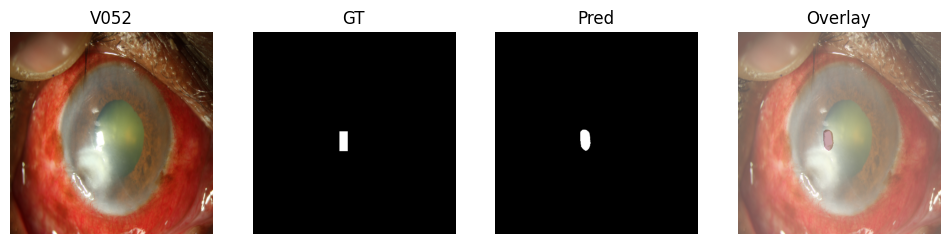

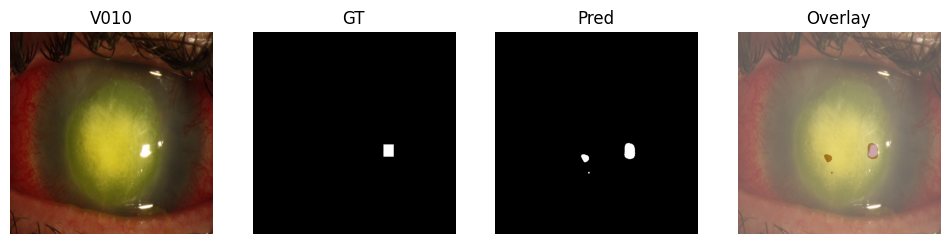

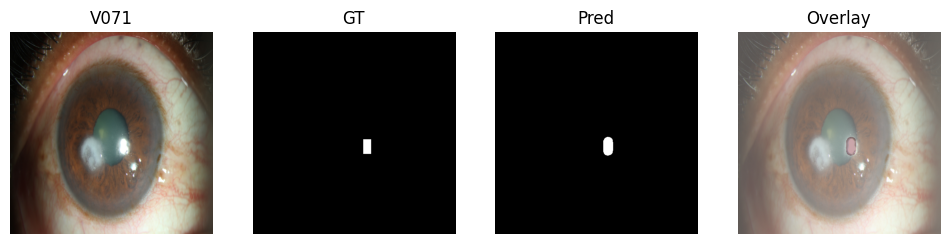

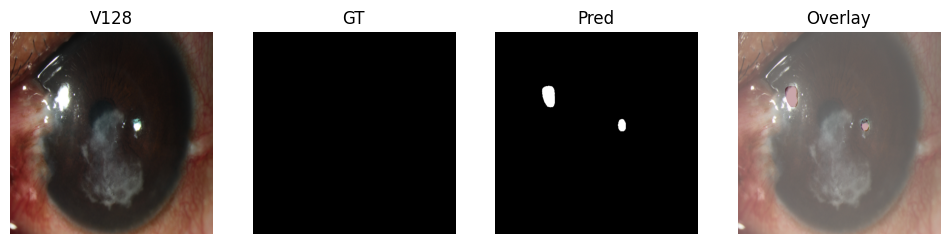

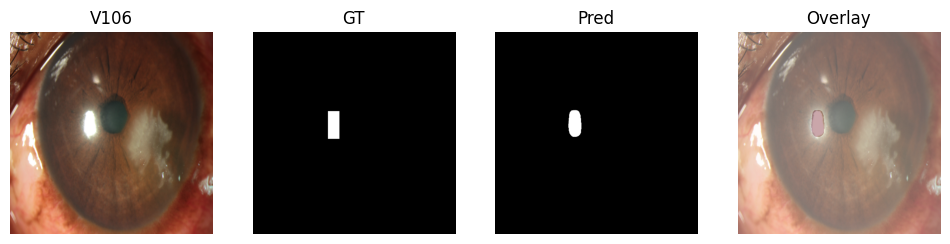

In [ ]:
import os, random
import cv2, numpy as np
import torch
import matplotlib.pyplot as plt

ROOT = "/content/drive/MyDrive/OpacityModelTraining2/SLITNet_processed"
OUT_DIR = "/content/drive/MyDrive/OpacityModelTraining2/runs/ulcer_unet"
IMG_DIR = os.path.join(ROOT, "images")
MSK_DIR = os.path.join(ROOT, "masks")
VAL_TXT = os.path.join(ROOT, "splits", "val.txt")

val_ids= [l.strip() for l in open(VAL_TXT).read().splitlines() if l.strip()]

from torchvision import models
import torch.nn as nn

class ConvBNReLU(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)

class UNetResNet34(nn.Module):
    def __init__(self, pretrained=False):
        super().__init__()
        base = models.resnet34(weights=None)
        self.stem = nn.Sequential(base.conv1, base.bn1, base.relu)
        self.pool = base.maxpool
        self.enc1 = base.layer1
        self.enc2 = base.layer2
        self.enc3 = base.layer3
        self.enc4 = base.layer4
        self.center = ConvBNReLU(512, 512)
        self.up4 = nn.ConvTranspose2d(512, 256, 2, 2); self.dec4 = ConvBNReLU(512, 256)
        self.up3 = nn.ConvTranspose2d(256, 128, 2, 2); self.dec3 = ConvBNReLU(256, 128)
        self.up2 = nn.ConvTranspose2d(128, 64, 2, 2);  self.dec2 = ConvBNReLU(128, 64)
        self.up1 = nn.ConvTranspose2d(64, 64, 2, 2);   self.dec1 = ConvBNReLU(128, 64)
        self.up0 = nn.ConvTranspose2d(64, 32, 2, 2);   self.dec0 = ConvBNReLU(32, 32)
        self.out = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        x0 = self.stem(x)
        x1 = self.enc1(self.pool(x0))
        x2 = self.enc2(x1)
        x3 = self.enc3(x2)
        x4 = self.enc4(x3)
        c = self.center(x4)
        u4 = self.up4(c);  d4 = self.dec4(torch.cat([u4, x3], 1))
        u3 = self.up3(d4); d3 = self.dec3(torch.cat([u3, x2], 1))
        u2 = self.up2(d3); d2 = self.dec2(torch.cat([u2, x1], 1))
        u1 = self.up1(d2); d1 = self.dec1(torch.cat([u1, x0], 1))
        u0 = self.up0(d1); d0 = self.dec0(u0)
        return self.out(d0)

#loading checkpoints
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt = torch.load(os.path.join(OUT_DIR, "best.pt"),map_location=device)
model = UNetResNet34(pretrained=False).to(device)
model.load_state_dict(ckpt["model"])
model.eval()

mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

def prep(img_rgb, size=512):
    img = cv2.resize(img_rgb, (size, size), interpolation=cv2.INTER_AREA)
    x = torch.from_numpy(img).permute(2,0,1).float()/255.0
    x = (x - mean) / std
    return x.unsqueeze(0)

#show few examples
for sid in random.sample(val_ids, k=min(5, len(val_ids))):
    img = cv2.cvtColor(cv2.imread(os.path.join(IMG_DIR, f"{sid}.png")), cv2.COLOR_BGR2RGB)
    msk = cv2.imread(os.path.join(MSK_DIR, f"{sid}.png"), 0)
    img512 = cv2.resize(img, (512,512), interpolation=cv2.INTER_AREA)
    msk512 = cv2.resize(msk, (512,512), interpolation=cv2.INTER_NEAREST)

    with torch.no_grad():
        logits = model(prep(img512, 512).to(device))
        prob = torch.sigmoid(logits)[0,0].cpu().numpy()
        pred = (prob > 0.5).astype(np.uint8)*255

    plt.figure(figsize=(12,4))
    plt.subplot(1,4,1); plt.title(sid); plt.imshow(img512); plt.axis("off")
    plt.subplot(1,4,2); plt.title("GT"); plt.imshow(msk512, cmap="gray"); plt.axis("off")
    plt.subplot(1,4,3); plt.title("Pred"); plt.imshow(pred, cmap="gray"); plt.axis("off")
    plt.subplot(1,4,4); plt.title("Overlay"); plt.imshow(img512); plt.imshow(pred, alpha=0.35, cmap="Reds"); plt.axis("off")
    plt.show()
